In [1]:
# Xác định Chu kỳ thị trường (Regime Detection) với Bitcoin.

# Mục tiêu: So sánh hai phương pháp phân loại trạng thái:


# Baseline: Moving Average Crossover (MA50/MA200).


# Proposed Method: Markov Switching Model (MSM) với bộ lọc nhiễu.

In [2]:
import os

current_dir = os.getcwd()
print(current_dir)
os.chdir("..")
print(os.getcwd())


/Users/giangluong/Desktop/MasterDS/Thesis/LuongThiGiang_Thesis_Code/notebooks
/Users/giangluong/Desktop/MasterDS/Thesis/LuongThiGiang_Thesis_Code


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression


In [4]:
# Data loading & log-return

DATA_FILE = Path("data/raw") / "BTC_USDT_1d.csv"

df = pd.read_csv(DATA_FILE)

df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.set_index("datetime")
df = df.sort_index()

# Tính log-return 
if "log_return" not in df.columns:
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

# Bỏ dòng đầu tiên bị NaN log_return
df = df.dropna(subset=["log_return"])

df.head()


,timestamp,open,high,low,close,volume,log_return
datetime,,,,,,,
2020-01-02 00:00:00+00:00,1577923200000,7200.77,7212.50,6924.74,6965.71,31951.483932,-0.033200
2020-01-03 00:00:00+00:00,1578009600000,6965.49,7405.00,6871.04,7344.96,68428.500451,0.053015
2020-01-04 00:00:00+00:00,1578096000000,7345.00,7404.00,7272.21,7354.11,29987.974977,0.001245
2020-01-05 00:00:00+00:00,1578182400000,7354.19,7495.00,7318.00,7358.75,38331.085604,0.000631
2020-01-06 00:00:00+00:00,1578268800000,7357.64,7795.34,7346.76,7758.00,54635.695316,0.052834


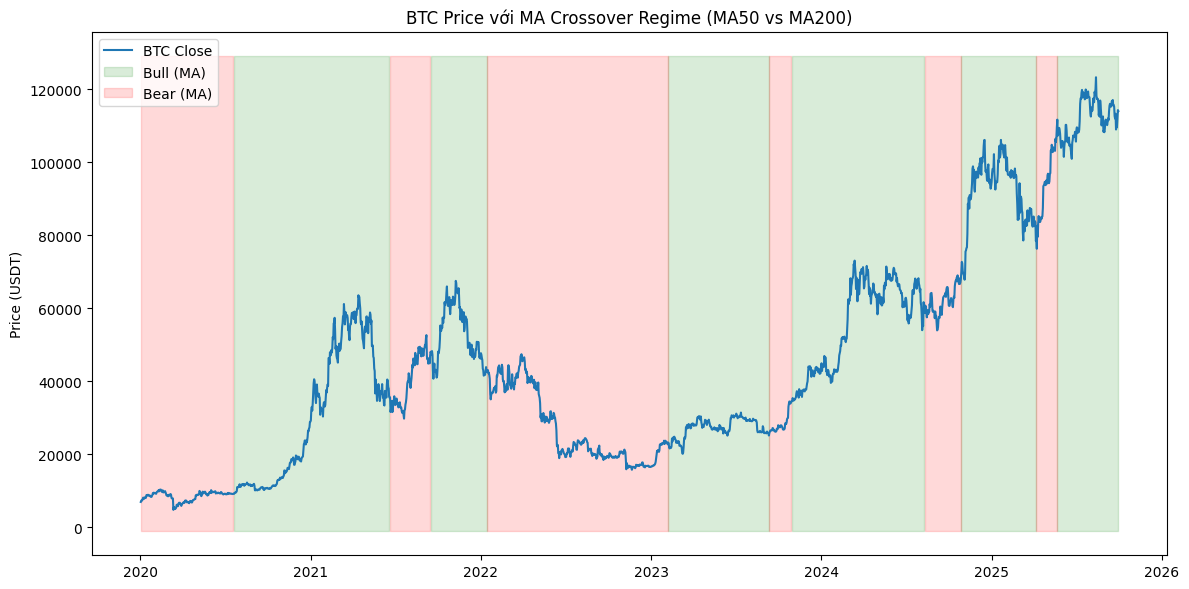

In [5]:
# MA Crossover baseline (Regime_MA)

SHORT_WINDOW = 50
LONG_WINDOW = 200

df["MA50"] = df["close"].rolling(window=SHORT_WINDOW).mean()
df["MA200"] = df["close"].rolling(window=LONG_WINDOW).mean()

# Regime: 1 = Bull, 0 = Bear
df["Regime_MA"] = np.where(df["MA50"] > df["MA200"], 1, 0)

# Plot giá BTC + nền màu theo Regime_MA
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df.index, df["close"], label="BTC Close")

# Lấy y-limits trước khi tô nền
ymin, ymax = ax.get_ylim()

bull = df["Regime_MA"] == 1
bear = df["Regime_MA"] == 0

ax.fill_between(df.index, ymin, ymax, where=bull, alpha=0.15, color="green", label="Bull (MA)")
ax.fill_between(df.index, ymin, ymax, where=bear, alpha=0.15, color="red", label="Bear (MA)")

ax.set_title("BTC Price với MA Crossover Regime (MA50 vs MA200)")
ax.set_ylabel("Price (USDT)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


--- Training on first 365 days ---
/Users/giangluong/Desktop/MasterDS/Thesis/crypto-cycle-portfolio-optimization/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
Training params:
p[0->0]        0.907309
p[1->0]        0.701448
const[0]       0.397569
const[1]       0.245789
sigma2[0]      5.555699
sigma2[1]    111.700624
dtype: float64
Regime Definition: State 1 = Bear (High Var), State 0 = Bull (Low Var)
/Users/giangluong/Desktop/MasterDS/Thesis/crypto-cycle-portfolio-optimization/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


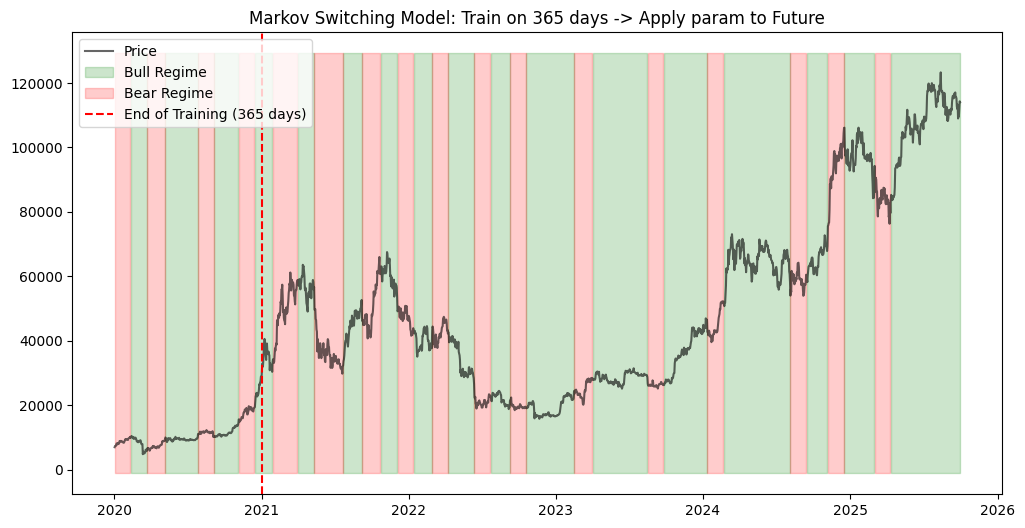

In [6]:
import numpy as np
import pandas as pd
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt

# --- 1. Chuẩn bị dữ liệu ---
returns = df["log_return"].dropna() * 100

# Tách train set (365 ngày đầu)
train_window = 365
train_data = returns.iloc[:train_window]

# --- 2. Huấn luyện mô hình trên 365 ngày đầu ---
print(f"--- Training on first {train_window} days ---")
model_train = MarkovRegression(
    endog=train_data,
    k_regimes=2,
    trend="c",
    switching_variance=True
)

# Fit mô hình
res_train = model_train.fit(maxiter=1000, search_reps=20, disp=False)
print("Training params:")
print(res_train.params)

# Xác định đâu là Bull/Bear dựa trên Variance của tập Train
# (Làm bước này để cố định định nghĩa Bull/Bear cho cả giai đoạn sau)
probs_train_0 = res_train.smoothed_marginal_probabilities[0]
probs_train_1 = res_train.smoothed_marginal_probabilities[1]

var0 = np.sum(probs_train_0 * (train_data - train_data.mean())**2) / probs_train_0.sum()
var1 = np.sum(probs_train_1 * (train_data - train_data.mean())**2) / probs_train_1.sum()

if var0 > var1:
    bear_state = 0
    bull_state = 1
else:
    bear_state = 1
    bull_state = 0
    
print(f"Regime Definition: State {bear_state} = Bear (High Var), State {bull_state} = Bull (Low Var)")

# --- 3. Áp dụng tham số đã học cho toàn bộ dữ liệu (Out-of-Sample application) ---
# Khởi tạo model trên TOÀN BỘ dữ liệu
model_full = MarkovRegression(
    endog=returns,
    k_regimes=2,
    trend="c",
    switching_variance=True
)

# Thay vì fit(), ta dùng smooth() với params từ res_train
# Hàm smooth(params) sẽ chạy bộ lọc Kalman/Hamilton filter áp dụng tham số cũ lên dữ liệu mới
res_applied = model_full.smooth(res_train.params)

# Lấy Filtered Probabilities (Xác suất thời gian thực, không nhìn trước tương lai)
filtered_prob_bull = res_applied.filtered_marginal_probabilities[bull_state]

# --- 4. Logic Filtering Rule

# Tính rolling volatility trên toàn bộ returns
vol_window = 30
vol_series = returns.rolling(window=vol_window).std()

# Hàm filtering rule 
def apply_filtering(probs_series, vol_series, prob_thresh=0.7, min_days=40, vol_percentile=75):
    signals = []
    current_state = 0 # 0 = Bear, 1 = Bull 
    days_in_state = 0
    
    # Tính ngưỡng Vol dựa trên dữ liệu quá khứ 
    vol_threshold = vol_series.quantile(vol_percentile / 100.0)

    for i in range(len(probs_series)):
        prob_bull = probs_series.iloc[i]
        current_vol = vol_series.iloc[i]

        # Xử lý NaN đầu chuỗi
        if np.isnan(current_vol): current_vol = 0

        # 1. Raw signal
        if prob_bull > prob_thresh:
            raw_signal = 1
        elif prob_bull < (1 - prob_thresh):
            raw_signal = 0
        else:
            raw_signal = current_state

        # 2. Volatility guard check
        if current_vol > vol_threshold and raw_signal == 1 and current_state == 0:
            raw_signal = 0

        # 3. Min days holding
        if raw_signal != current_state:
            if days_in_state < min_days:
                final_signal = current_state
                days_in_state += 1
            else:
                final_signal = raw_signal
                current_state = final_signal
                days_in_state = 1
        else:
            final_signal = current_state
            days_in_state += 1

        signals.append(final_signal)

    return pd.Series(signals, index=probs_series.index)

# Chạy filter
regime_msm_filtered = apply_filtering(
    probs_series=filtered_prob_bull,
    vol_series=vol_series,
    prob_thresh=0.7,
    min_days=40,
    vol_percentile=75
)

# Gán vào DF
df["Regime_MSM"] = regime_msm_filtered.reindex(df.index).ffill()

# Visualization kiểm tra
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, df['close'], label='Price', color='black', alpha=0.6)

y_min, y_max = ax.get_ylim()
ax.fill_between(df.index, y_min, y_max, where=(df["Regime_MSM"] == 1), color='green', alpha=0.2, label='Bull Regime')
ax.fill_between(df.index, y_min, y_max, where=(df["Regime_MSM"] == 0), color='red', alpha=0.2, label='Bear Regime')

# Vẽ vạch phân chia Train/Test
train_end_date = df.index[train_window]
ax.axvline(x=train_end_date, color='red', linestyle='--', label='End of Training (365 days)')

plt.legend(loc="upper left")
plt.title("Markov Switching Model: Train on 365 days -> Apply param to Future")
plt.show()

=== Thống kê chuyển trạng thái Regime ===
MA Crossover   - Số lần chuyển: 12, Thời gian trung bình: 174.92 ngày
MSM (đã lọc)   - Số lần chuyển: 34, Thời gian trung bình: 61.74 ngày
Combined       - Số lần chuyển: 49, Thời gian trung bình: 42.84 ngày


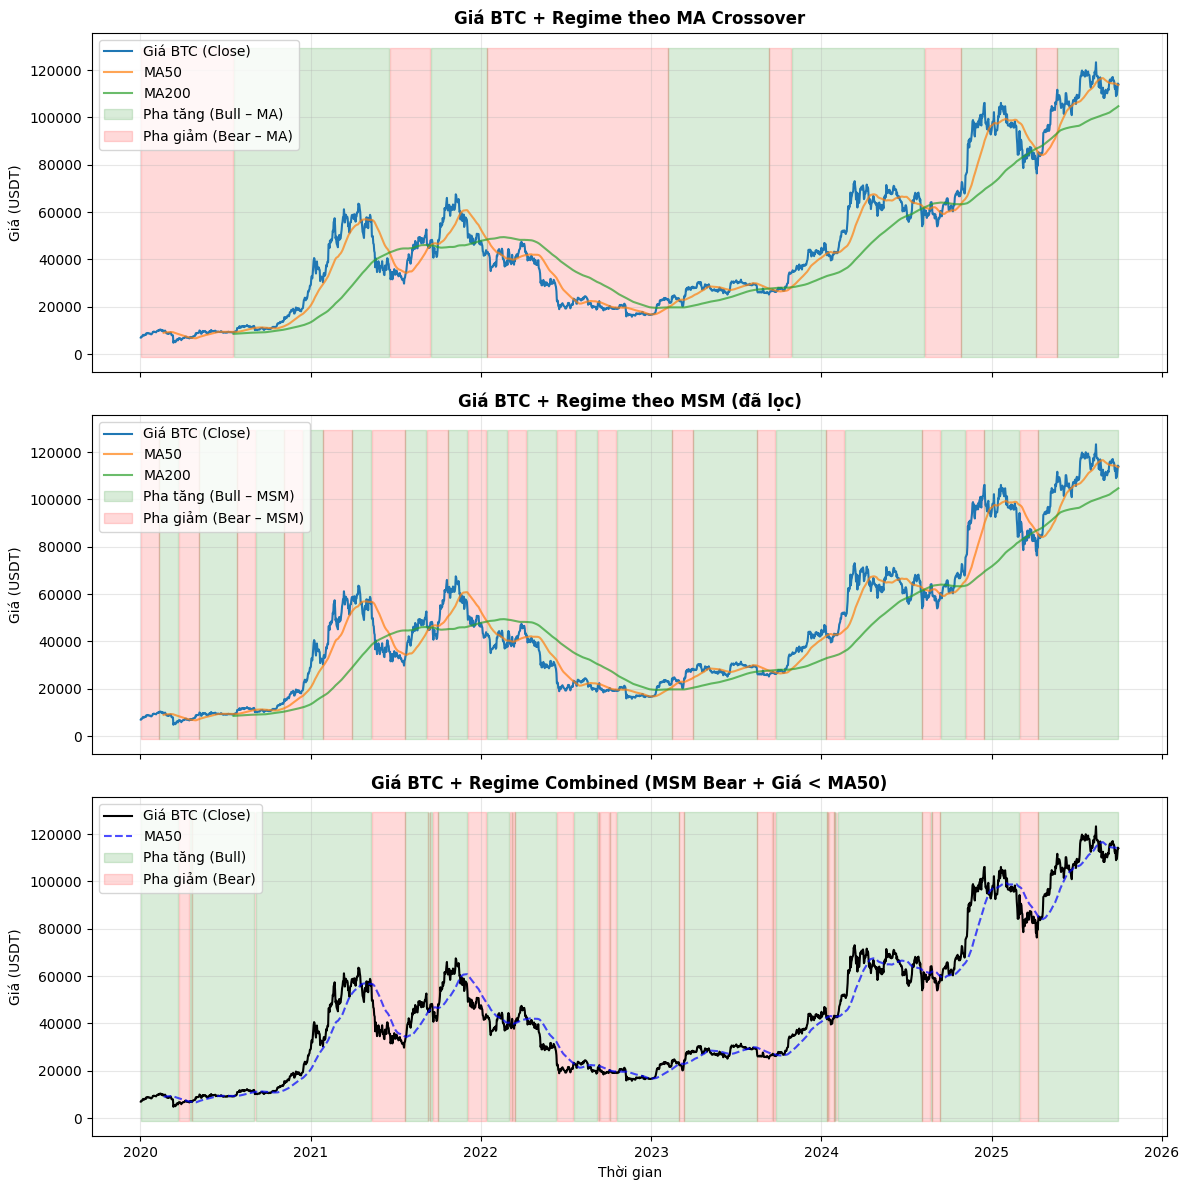


=== Phân bố Regime Combined ===
Bull (1): 1722 ngày (82.04%)
Bear (0): 377 ngày (17.96%)


In [7]:
# Đánh giá – số lần chuyển trạng thái và thời gian trung bình
def count_switches(series: pd.Series) -> int:
    s = series.dropna()
    return (s != s.shift(1)).sum()

def avg_duration(series: pd.Series) -> float:
    s = series.dropna()
    changes = s != s.shift(1)
    groups = changes.cumsum()
    durations = s.groupby(groups).size()
    return durations.mean()

# ============================================
# MÔ HÌNH KẾT HỢP MSM + MA50
# ============================================
# Pha Bear: MSM = 0 (Bear) VÀ giá < MA50
# Pha Bull: Các trường hợp còn lại
df["Regime_Combined"] = 1  # Mặc định là Bull

# Chỉ là Bear khi đồng thời: MSM = Bear VÀ giá dưới MA50
bear_condition = (df["Regime_MSM"] == 0) & (df["close"] < df["MA50"])
df.loc[bear_condition, "Regime_Combined"] = 0

# Tính thống kê cho 3 phương pháp
ma_switches = count_switches(df["Regime_MA"])
msm_switches = count_switches(df["Regime_MSM"])
combined_switches = count_switches(df["Regime_Combined"])

ma_avg_duration = avg_duration(df["Regime_MA"])
msm_avg_duration = avg_duration(df["Regime_MSM"])
combined_avg_duration = avg_duration(df["Regime_Combined"])

print("=== Thống kê chuyển trạng thái Regime ===")
print(f"MA Crossover   - Số lần chuyển: {ma_switches}, Thời gian trung bình: {ma_avg_duration:.2f} ngày")
print(f"MSM (đã lọc)   - Số lần chuyển: {msm_switches}, Thời gian trung bình: {msm_avg_duration:.2f} ngày")
print(f"Combined       - Số lần chuyển: {combined_switches}, Thời gian trung bình: {combined_avg_duration:.2f} ngày")

# Plot so sánh: 3 subplot – MA vs MSM vs Combined
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# ======================
# Subplot 1: Regime theo MA
# ======================
axes[0].plot(df.index, df["close"], label="Giá BTC (Close)", linewidth=1.5)
axes[0].plot(df.index, df["MA50"], label="MA50", alpha=0.7)
axes[0].plot(df.index, df["MA200"], label="MA200", alpha=0.7)

ymin, ymax = axes[0].get_ylim()
bull_ma = df["Regime_MA"] == 1
bear_ma = df["Regime_MA"] == 0

axes[0].fill_between(df.index, ymin, ymax, where=bull_ma,
                     color="green", alpha=0.15,
                     label="Pha tăng (Bull – MA)")
axes[0].fill_between(df.index, ymin, ymax, where=bear_ma,
                     color="red", alpha=0.15,
                     label="Pha giảm (Bear – MA)")

axes[0].set_title("Giá BTC + Regime theo MA Crossover", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Giá (USDT)")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# ======================
# Subplot 2: Regime theo MSM
# ======================
axes[1].plot(df.index, df["close"], label="Giá BTC (Close)", linewidth=1.5)
axes[1].plot(df.index, df["MA50"], label="MA50", alpha=0.7)
axes[1].plot(df.index, df["MA200"], label="MA200", alpha=0.7)

ymin, ymax = axes[1].get_ylim()
bull_msm = df["Regime_MSM"] == 1
bear_msm = df["Regime_MSM"] == 0

axes[1].fill_between(df.index, ymin, ymax, where=bull_msm,
                     color="green", alpha=0.15,
                     label="Pha tăng (Bull – MSM)")
axes[1].fill_between(df.index, ymin, ymax, where=bear_msm,
                     color="red", alpha=0.15,
                     label="Pha giảm (Bear – MSM)")

axes[1].set_title("Giá BTC + Regime theo MSM (đã lọc)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Giá (USDT)")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

# ======================
# Subplot 3: Regime Combined (MSM + MA50)
# ======================
axes[2].plot(df.index, df["close"], label="Giá BTC (Close)", linewidth=1.5, color='black')
axes[2].plot(df.index, df["MA50"], label="MA50", alpha=0.7, linestyle='--', color='blue')

ymin, ymax = axes[2].get_ylim()
bull_combined = df["Regime_Combined"] == 1
bear_combined = df["Regime_Combined"] == 0

axes[2].fill_between(df.index, ymin, ymax, where=bull_combined,
                     color="green", alpha=0.15,
                     label="Pha tăng (Bull)")
axes[2].fill_between(df.index, ymin, ymax, where=bear_combined,
                     color="red", alpha=0.15,
                     label="Pha giảm (Bear)")

axes[2].set_title("Giá BTC + Regime Combined (MSM Bear + Giá < MA50)", 
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel("Giá (USDT)")
axes[2].set_xlabel("Thời gian")
axes[2].legend(loc="upper left")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Thống kê phân bố regime Combined
print("\n=== Phân bố Regime Combined ===")
regime_counts = df["Regime_Combined"].value_counts()
regime_pct = df["Regime_Combined"].value_counts(normalize=True) * 100

print(f"Bull (1): {regime_counts.get(1, 0)} ngày ({regime_pct.get(1, 0):.2f}%)")
print(f"Bear (0): {regime_counts.get(0, 0)} ngày ({regime_pct.get(0, 0):.2f}%)")

In [8]:
df["Regime_Combined"].head()

datetime
2020-01-02 00:00:00+00:00    1
2020-01-03 00:00:00+00:00    1
2020-01-04 00:00:00+00:00    1
2020-01-05 00:00:00+00:00    1
2020-01-06 00:00:00+00:00    1
Name: Regime_Combined, dtype: int64

In [9]:
#  Export regimes to CSV

from pathlib import Path

OUTPUT_FILE = Path("data/processed") / "btc_regimes.csv"

df_regimes = pd.DataFrame({
    "BTC_Price": df["close"],
    "Log_Return": df["log_return"],
    "Regime_MA": df["Regime_MA"],
    "Regime_MSM": df["Regime_MSM"], 
    "Regime_Combined": df["Regime_Combined"]
})
df_regimes.index.name = "date"

df_regimes.to_csv(OUTPUT_FILE)
print(f"Saved regimes dataframe to {OUTPUT_FILE}")
df_regimes.head()


Saved regimes dataframe to data/processed/btc_regimes.csv


,BTC_Price,Log_Return,Regime_MA,Regime_MSM,Regime_Combined
date,,,,,
2020-01-02 00:00:00+00:00,6965.71,-0.033200,0,0,1
2020-01-03 00:00:00+00:00,7344.96,0.053015,0,0,1
2020-01-04 00:00:00+00:00,7354.11,0.001245,0,0,1
2020-01-05 00:00:00+00:00,7358.75,0.000631,0,0,1
2020-01-06 00:00:00+00:00,7758.00,0.052834,0,0,1


In [10]:
# Phân tích đặc tính Regime Bull / Bear (MSM)

# Dùng log_return gốc (chưa nhân 100) để phân tích
df_msm_stats = df.dropna(subset=["log_return", "Regime_MSM"]).copy()
 

TRADING_DAYS = 365  # giả định 365 ngày giao dịch / năm

def describe_regime(df_stats: pd.DataFrame,model_name, regime_value: int, label: str):
    sub = df_stats[df_stats[model_name] == regime_value]

    if len(sub) == 0:
        print(f"\n=== {label} Regime (Regime = {regime_value}) ===")
        print("Không có dữ liệu cho regime này.")
        return

    n_days = len(sub)
    weight = n_days / len(df_stats) * 100

    # log_return dạng ln(P_t / P_{t-1})
    daily_ret = sub["log_return"].mean()
    daily_vol = sub["log_return"].std()

    # Annualized theo log-return
    ann_ret = daily_ret * TRADING_DAYS
    ann_vol = daily_vol * np.sqrt(TRADING_DAYS)

    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    print(f"\n=== {label} Regime (Regime = {regime_value}) ===")
    print(f"Số ngày: {n_days} ({weight:.2f}% thời gian)")
    print(f"Lợi suất trung bình (daily): {daily_ret * 100:.3f}%")
    print(f"Biến động (daily vol): {daily_vol * 100:.3f}%")
    print(f"Lợi suất năm hoá (log ~): {ann_ret * 100:.2f}%")
    print(f"Volatility năm hoá: {ann_vol * 100:.2f}%")
    print(f"Sharpe xấp xỉ (rf=0): {sharpe:.2f}")


print("\n===== MSM Regime Statistics (dựa trên log_return) =====")
describe_regime(df_msm_stats,"Regime_MSM", 1, "Bull")
describe_regime(df_msm_stats,"Regime_MSM", 0, "Bear")



===== MSM Regime Statistics (dựa trên log_return) =====

=== Bull Regime (Regime = 1) ===
Số ngày: 1350 (64.32% thời gian)
Lợi suất trung bình (daily): 0.075%
Biến động (daily vol): 3.101%
Lợi suất năm hoá (log ~): 27.25%
Volatility năm hoá: 59.24%
Sharpe xấp xỉ (rf=0): 0.46

=== Bear Regime (Regime = 0) ===
Số ngày: 749 (35.68% thời gian)
Lợi suất trung bình (daily): 0.234%
Biến động (daily vol): 3.708%
Lợi suất năm hoá (log ~): 85.51%
Volatility năm hoá: 70.85%
Sharpe xấp xỉ (rf=0): 1.21


In [11]:

# Phân tích đặc tính Regime Bull / Bear (Mô hình kết hợp)

# Dùng log_return gốc (chưa nhân 100) để phân tích
df_combined_stats = df.dropna(subset=["log_return", "Regime_Combined"]).copy()

describe_regime(df_combined_stats,"Regime_Combined", 1, "Bull")
describe_regime(df_combined_stats,"Regime_Combined", 0, "Bear")



=== Bull Regime (Regime = 1) ===
Số ngày: 1722 (82.04% thời gian)
Lợi suất trung bình (daily): 0.255%
Biến động (daily vol): 3.196%
Lợi suất năm hoá (log ~): 92.96%
Volatility năm hoá: 61.05%
Sharpe xấp xỉ (rf=0): 1.52

=== Bear Regime (Regime = 0) ===
Số ngày: 377 (17.96% thời gian)
Lợi suất trung bình (daily): -0.431%
Biến động (daily vol): 3.842%
Lợi suất năm hoá (log ~): -157.14%
Volatility năm hoá: 73.40%
Sharpe xấp xỉ (rf=0): -2.14


In [12]:
# So sánh đặc tính Regime giữa MSM và MA50/200

from sklearn.metrics import confusion_matrix, classification_report

TRADING_DAYS = 365  # giả định 365 ngày/năm

def summarize_regime(df_stats: pd.DataFrame,
                     regime_col: str,
                     regime_value: int,
                     method_label: str,
                     regime_label: str):
    sub = df_stats[df_stats[regime_col] == regime_value]

    if len(sub) == 0:
        return {
            "Phương pháp": method_label,
            "Regime": regime_label,
            "Số ngày": 0,
            "Tỷ lệ_%": 0.0,
            "Lợi nhuận TB ngày_%": np.nan,
            "Độ lệch chuẩn ngày_%": np.nan,
            "Lợi nhuận năm hóa_%": np.nan,
            "Biến động năm hóa_%": np.nan,
            "Sharpe (xấp xỉ)": np.nan,
        }

    n_days = len(sub)
    weight = n_days / len(df_stats) * 100

    daily_ret = sub["log_return"].mean()
    daily_vol = sub["log_return"].std()

    ann_ret = daily_ret * TRADING_DAYS
    ann_vol = daily_vol * np.sqrt(TRADING_DAYS)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else np.nan

    return {
        "Phương pháp": method_label,
        "Regime": regime_label,
        "Số ngày": n_days,
        "Tỷ lệ_%": weight,
        "Lợi nhuận TB ngày_%": daily_ret * 100,
        "Độ lệch chuẩn ngày_%": daily_vol * 100,
        "Lợi nhuận năm hóa_%": ann_ret * 100,
        "Biến động năm hóa_%": ann_vol * 100,
        "Sharpe (xấp xỉ)": sharpe,
    }


# Chuẩn bị dữ liệu chung cho thống kê
df_stats_all = df.dropna(subset=["log_return", "Regime_MSM", "Regime_MA"]).copy()

rows = []
# MSM Bull (1), Bear (0)
rows.append(summarize_regime(df_stats_all, "Regime_MSM", 1, "MSM", "Pha tăng (Bull)"))
rows.append(summarize_regime(df_stats_all, "Regime_MSM", 0, "MSM", "Pha giảm (Bear)"))
# MA Bull (1), Bear (0)
rows.append(summarize_regime(df_stats_all, "Regime_MA", 1, "MA50/200", "Pha tăng (Bull)"))
rows.append(summarize_regime(df_stats_all, "Regime_MA", 0, "MA50/200", "Pha giảm (Bear)"))

summary_df = pd.DataFrame(rows)

print("\n===== So sánh đặc tính Regime: MSM vs MA50/200 =====")
print(summary_df.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

# =====================================================
# So sánh phân loại: MA Regime vs MSM Regime (trên cùng mẫu)
# =====================================================

df_compare = df_stats_all.copy()

print("\n===== So sánh phân loại Regime: MSM so với MA50/200 =====")
agreement = (df_compare["Regime_MA"] == df_compare["Regime_MSM"]).mean() * 100
print(f"Tỷ lệ trùng khớp regime: {agreement:.2f}%")

cm = confusion_matrix(df_compare["Regime_MA"], df_compare["Regime_MSM"])
print("\nMa trận nhầm lẫn (Confusion Matrix)")
print("Hàng: Regime theo MA50/200, Cột: Regime theo MSM")
print("Hàng 0 = Pha giảm (Bear - MA), Hàng 1 = Pha tăng (Bull - MA)")
print("Cột 0 = Pha giảm (Bear - MSM), Cột 1 = Pha tăng (Bull - MSM)")
print(cm)

print("\nBáo cáo phân loại (coi MA50/200 là chuẩn tham chiếu):")
print(classification_report(
    df_compare["Regime_MA"],
    df_compare["Regime_MSM"],
    target_names=["Pha giảm (Bear)", "Pha tăng (Bull)"]
))



===== So sánh đặc tính Regime: MSM vs MA50/200 =====
Phương pháp          Regime  Số ngày  Tỷ lệ_%  Lợi nhuận TB ngày_%  Độ lệch chuẩn ngày_%  Lợi nhuận năm hóa_%  Biến động năm hóa_%  Sharpe (xấp xỉ)
        MSM Pha tăng (Bull)     1350    64.32                 0.07                  3.10                27.25                59.24             0.46
        MSM Pha giảm (Bear)      749    35.68                 0.23                  3.71                85.51                70.85             1.21
   MA50/200 Pha tăng (Bull)     1251    59.60                 0.17                  3.08                61.55                58.90             1.04
   MA50/200 Pha giảm (Bear)      848    40.40                 0.08                  3.67                28.11                70.04             0.40

===== So sánh phân loại Regime: MSM so với MA50/200 =====
Tỷ lệ trùng khớp regime: 52.31%

Ma trận nhầm lẫn (Confusion Matrix)
Hàng: Regime theo MA50/200, Cột: Regime theo MSM
Hàng 0 = Pha giảm (Bear - MA)